# 10-3-1 Visdom Example

Visdom is a visualization tool that helps with visualizing data in real-time. It is particularly useful for machine learning experiments, allowing users to visualize loss, accuracy, images, and other metrics during training. Visdom supports various types of plots, including line plots, scatter plots, bar plots, and images.

In [1]:
import torch
import torch.nn as nn

import torchvision
import torchvision.datasets as dsets

## import visdom

![](figs/turn_on_terminal.png)

Open terminal and run `python -m visdom.server` to start visdom server.

In [2]:
import visdom
vis = visdom.Visdom()

Setting up a new session...


## Text

In [3]:
vis.text("Hello, world!",env="main")

'window_3ddd7c57e28260'

## image

In [4]:
a=torch.randn(3,200,200)
vis.image(a)

'window_3ddd7c64fbe8b4'

## images

In [5]:
vis.images(torch.Tensor(3,3,28,28))

/usr/local/lib/python3.12/dist-packages/visdom/__init__.py:1402: RuntimeWarning: invalid value encountered in cast
  grid[:, h_start:h_end, w_start:w_end] = tensor[k]
/usr/local/lib/python3.12/dist-packages/visdom/__init__.py:1320: RuntimeWarning: invalid value encountered in cast
  img = np.uint8(img)


'window_3ddd7c69b14c36'

## example (using MNIST and CIFAR10)

In [6]:
# 시간이 좀 걸립니다.
MNIST = dsets.MNIST(root="./MNIST_data",train = True,transform=torchvision.transforms.ToTensor(), download=True)
cifar10 = dsets.CIFAR10(root="./cifar10",train = True, transform=torchvision.transforms.ToTensor(),download=True)

Files already downloaded and verified


#### CIFAR10

In [7]:
data = cifar10.__getitem__(0)
print(data[0].shape)
vis.images(data[0],env="main")

torch.Size([3, 32, 32])


'window_3ddd7c705c4b00'

#### MNIST

In [8]:
data = MNIST.__getitem__(0)
print(data[0].shape)
vis.images(data[0],env="main")

torch.Size([1, 28, 28])


'window_3ddd7c72e5323c'

#### Check dataset

In [9]:
data_loader = torch.utils.data.DataLoader(dataset = MNIST,
                                          batch_size = 32,
                                          shuffle = False)

In [10]:
for num, value in enumerate(data_loader):
    value = value[0]
    print(value.shape)
    vis.images(value)
    break

torch.Size([32, 1, 28, 28])


In [11]:
vis.close(env="main")

''

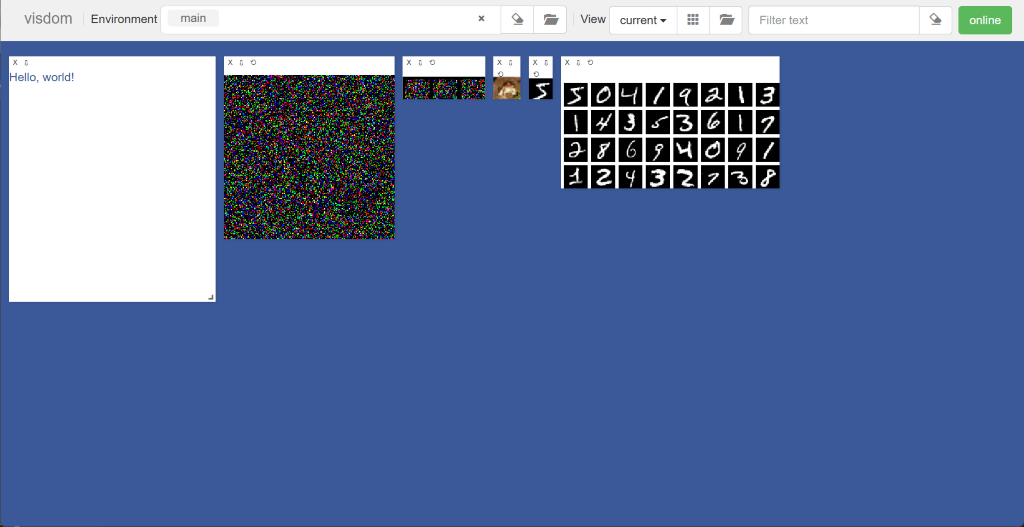

## Line Plot

In [12]:
Y_data = torch.randn(5)
plt = vis.line (Y=Y_data)

In [13]:
X_data = torch.Tensor([1,2,3,4,5])
plt = vis.line(Y=Y_data, X=X_data)

### Line update

In [14]:
Y_append = torch.randn(1)
X_append = torch.Tensor([6])

vis.line(Y=Y_append, X=X_append, win=plt, update='append')

'window_3ddd7cb93904b8'

### multiple Line on single windows

In [15]:
num = torch.Tensor(list(range(0,10)))
num = num.view(-1,1)
num = torch.cat((num,num),dim=1)

plt = vis.line(Y=torch.randn(10,2), X = num)

### Line info

In [16]:
plt = vis.line(Y=Y_data, X=X_data, opts = dict(title='Test', showlegend=True))

In [18]:
plt = vis.line(Y=Y_data, X=X_data, opts = dict(title='Test', legend = ['1번'],showlegend=True))

In [17]:
plt = vis.line(Y=torch.randn(10,2), X = num, opts=dict(title='Test', legend=['1번','2번'],showlegend=True))

## make function for update line

In [19]:
def loss_tracker(loss_plot, loss_value, num):
    '''num, loss_value, are Tensor'''
    vis.line(X=num,
             Y=loss_value,
             win = loss_plot,
             update='append'
             )

In [20]:
plt = vis.line(Y=torch.Tensor(1).zero_())

for i in range(500):
    loss = torch.randn(1) + i
    loss_tracker(plt, loss, torch.Tensor([i]))

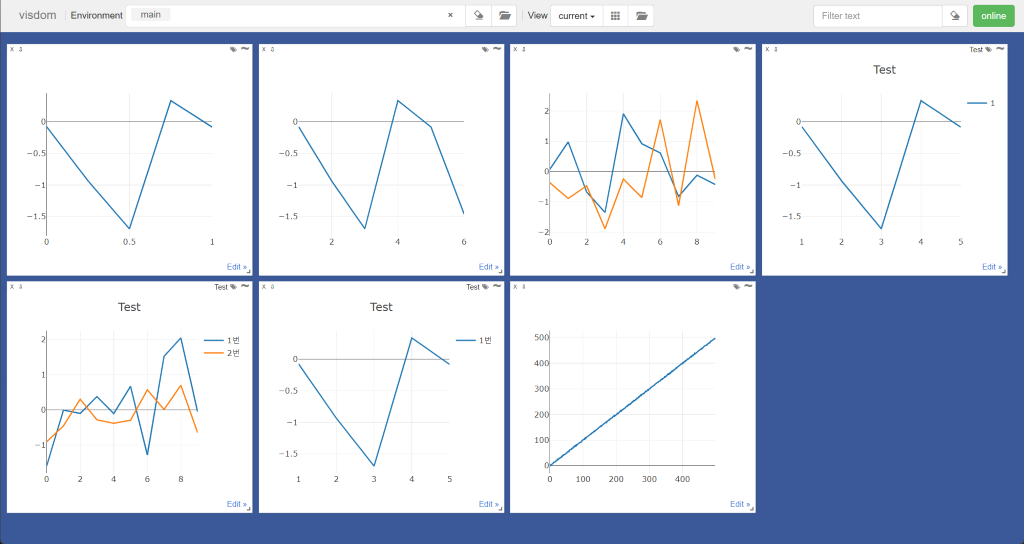

## close the window

In [50]:
vis.close(env="main")

''